<a href="https://colab.research.google.com/github/Iddrisu-Abdulai/Analysis_Python/blob/main/CatvsDog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing libraries

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2




In [ ]:
# Download the Cats vs Dogs dataset
_URL = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'
path_to_zip = tf.keras.utils.get_file('cats_and_dogs.zip', origin=_URL, extract=True)
PATH = os.path.join(os.path.dirname(path_to_zip), 'cats_and_dogs_filtered')

train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')

BATCH_SIZE = 32
IMG_SIZE = 32

In [ ]:


def custom_cutout(img):
    """Applies Cutout augmentation."""
    h, w, _ = img.shape
    cutout_size = int(min(h, w) * 0.2)  # Cutout size is 20% of the smaller dimension
    x = np.random.randint(0, w - cutout_size)
    y = np.random.randint(0, h - cutout_size)
    img[y:y + cutout_size, x:x + cutout_size, :] = 0  # Fill cutout region with black
    return img

    # Define image dimensions
IMG_HEIGHT = 150
IMG_WIDTH = 150


# Creating image generators
train_data_gen = ImageDataGenerator(rescale=1./255, preprocessing_function=custom_cutout)
validation_data_gen = ImageDataGenerator(rescale=1./255)
test_data_gen = ImageDataGenerator(rescale=1./255)



In [ ]:
# Creating data generators for each dataset
train_generator = train_data_gen.flow_from_directory(
    train_dir,  # Use the correct path to the training data
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=20,
    class_mode='binary')

validation_generator = validation_data_gen.flow_from_directory(
    validation_dir,  # Use the correct path to the validation data
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=20,
    class_mode='binary')

# Instead of assuming a 'test' directory, use validation_dir for test as well:
test_generator = test_data_gen.flow_from_directory(
    validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=20,
    class_mode='binary',
    shuffle=False)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


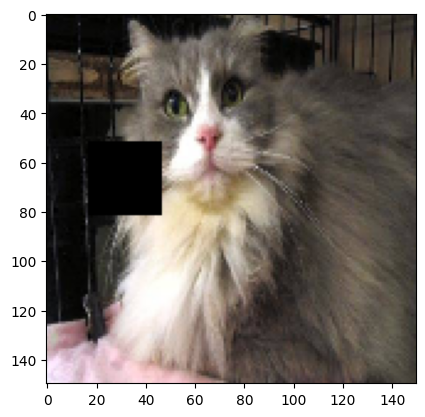

In [ ]:
# Get a batch of images and labels from the train_generator
images, labels = next(train_generator)

# Display the first image in the batch
IMG_INDEX = 0  # Set to 0 to access the first image
plt.imshow(images[IMG_INDEX])  # Remove cmap='plt.cm.binary' as images are likely RGB
plt.show()

In [ ]:
# Data preprocessing with random transformations
train_datagen = ImageDataGenerator(
    rescale=1./255,            # Rescale pixel values to [0, 1]
    rotation_range=40,         # Randomly rotate images by up to 40 degrees
    width_shift_range=0.2,      # Randomly shift images horizontally by up to 20% of the width
    height_shift_range=0.2,     # Randomly shift images vertically by up to 20% of the height
    shear_range=0.2,           # Apply random shear transformations
    zoom_range=0.2,            # Randomly zoom in or out on images by up to 20%
    horizontal_flip=True,       # Randomly flip images horizontally
    fill_mode='nearest'        # Fill in newly created pixels (due to transformations) using nearest neighbor
)

# Keep the test_datagen as before
test_datagen = ImageDataGenerator(rescale=1./255)

# Recreate the train_generator using the augmented train_datagen
train_generator = train_datagen.flow_from_directory(
    train_dir,  # Use the correct path to the training data
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=20,
    class_mode='binary')

# Keep the validation_generator as before
validation_generator = test_datagen.flow_from_directory(
    validation_dir,  # Use the correct path to the validation data
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=20,
    class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [ ]:
# Define the CNN model
model = keras.Sequential([
    # Convolutional layers
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    #Add dropout with a rate of 0.2
    layers.Dropout(0.2),
    # Flatten the output from convolutional layers
    layers.Flatten(),

    # Fully connected layer with ReLU activation
    layers.Dense(512, activation='relu'),

    # Output layer with sigmoid activation for binary classification
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
optimizer = keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=100,  # Number of batches per epoch (adjust based on your dataset size)
    epochs=10,            # Number of training epochs (adjust as needed)
    validation_data=validation_generator,
    validation_steps=50   # Number of batches for validation (adjust based on your dataset size)
)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.5102 - loss: 0.7308 - val_accuracy: 0.6210 - val_loss: 0.6674
Epoch 2/10


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.5896 - loss: 0.6747 - val_accuracy: 0.6270 - val_loss: 0.6246
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.6490 - loss: 0.6158 - val_accuracy: 0.6680 - val_loss: 0.6054
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 189us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.6622 - loss: 0.6092 - val_accuracy: 0.6550 - val_loss: 0.6050
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.6920 - loss: 0.5699 - val_accuracy: 0.7040 - val_loss: 0.5617
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00


50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 337ms/step


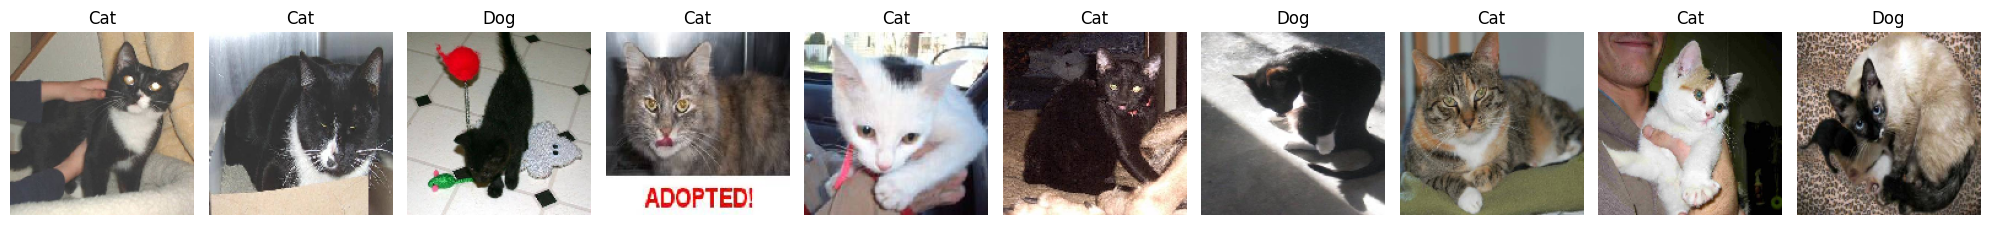

In [ ]:
# Get probabilities for each test image
probabilities = model.predict(test_generator)
probabilities = [int(round(p[0])) for p in probabilities]  # Convert to integers (0 or 1)

# Define plotImages function
def plotImages(images_arr, probabilities):
    fig, axes = plt.subplots(1, 10, figsize=(20, 20))
    axes = axes.flatten()
    for img, ax, prob in zip(images_arr, axes, probabilities):
        ax.imshow(img)
        ax.axis('off')
        ax.set_title("Cat" if prob == 0 else "Dog")  # Assuming 0 for cat, 1 for dog
    plt.tight_layout()
    plt.show()

# Get a batch of test images
test_images, _ = next(test_generator)

# Plot images with predictions
plotImages(test_images, probabilities[:len(test_images)])

In [ ]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(test_generator, steps=len(test_generator))

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 300ms/step - accuracy: 0.6935 - loss: 0.5895
Test Loss: 0.5616574883460999
Test Accuracy: 0.7039999961853027


In [ ]:
# Evaluate the model on the training data
train_loss, train_accuracy = model.evaluate(train_generator, steps=len(train_generator))

print("Train Loss:", train_loss)
print("Train Accuracy:", train_accuracy)

100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 417ms/step - accuracy: 0.7280 - loss: 0.5619
Train Loss: 0.5643747448921204
Train Accuracy: 0.718999981880188
